In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit.quantum_info import Statevector


def deutsch_function(case: int):


    if case not in [1, 2, 3, 4]:
        raise ValueError("`case` must be 1, 2, 3, or 4.")

    f = QuantumCircuit(2)
    if case in [2, 3]:
        f.cx(0, 1)
    if case in [3, 4]:
        f.x(1)
    return f

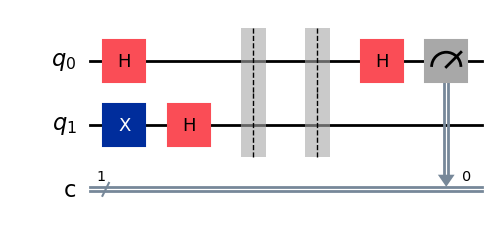

constant
balanced
{'0': 1024}


In [ ]:
deutsch_func = deutsch_function(1)

qc = QuantumCircuit(2, 1) 
qc.x(1)
qc.h(0)
qc.h(1)

qc.barrier()
qc.compose(deutsch_func, inplace =True)
qc.barrier()

qc.h(0)

qc.measure(0, 0)  

display(qc.draw('mpl'))

result = AerSimulator().run(qc, shots=1, memory=True).result()
measurements = result.get_memory()

if measurements[0] == "0":
   print("constant")
print("balanced")


sim = Aer.get_backend('aer_simulator')
qc_compiled = transpile(qc, sim)
job = sim.run(qc_compiled, shots=1024)

result = job.result()
counts = result.get_counts()

print(counts)

In [ ]:
qc = QuantumCircuit(3, 1) 
qc.x(0)
qc.x(1)
qc.cx(0, 2)
qc.cx(1, 2)

qc.measure(2,0)
display(qc.draw('mpl'))